In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Project Title: Education Dropout Prediction

**Goal:** Build a Logistic Regression model to predict whether a student will drop out (`Dropped_Out` = 1) based on their academic and socio-economic performance metrics like `Attendance_Percentage`, `Previous_Grades`, `Study_Hours_Per_Week`, and `Family_Income`.
This notebook covers data loading, missing value imputation, outlier treatment, and model evaluation.

## 1. Data Loading

In [6]:
df = pd.read_csv('/content/student_dropout_data (1).csv')
print('Shape:', df.shape)
display(df.head())

Shape: (4000, 5)


,Study_Hours_Per_Week,Attendance_Percentage,Previous_Grades,Family_Income,Dropped_Out
0,17.6,90.7,74.1,69149.19,0
1,24.5,75.8,79.8,54179.74,0
2,28.7,95.2,82.2,74654.73,0
3,25.5,84.6,79.1,97152.00,0
4,1.9,40.5,63.9,58080.17,1


## 2. Checking and Treating Null Values

In [7]:
print("Null values BEFORE treatment:\n")
print(df.isnull().sum())

# Impute missing values with the median (robust to outliers)
for col in ['Study_Hours_Per_Week', 'Attendance_Percentage']:
    df[col].fillna(df[col].median(), inplace=True)

print("\nNull values AFTER treatment:\n")
print(df.isnull().sum())

Null values BEFORE treatment:

Study_Hours_Per_Week     100
Attendance_Percentage    150
Previous_Grades            0
Family_Income              0
Dropped_Out                0
dtype: int64

Null values AFTER treatment:

Study_Hours_Per_Week     0
Attendance_Percentage    0
Previous_Grades          0
Family_Income            0
Dropped_Out              0
dtype: int64


/tmp/ipykernel_7048/3505709639.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


## 3. Visualizing and Treating Outliers

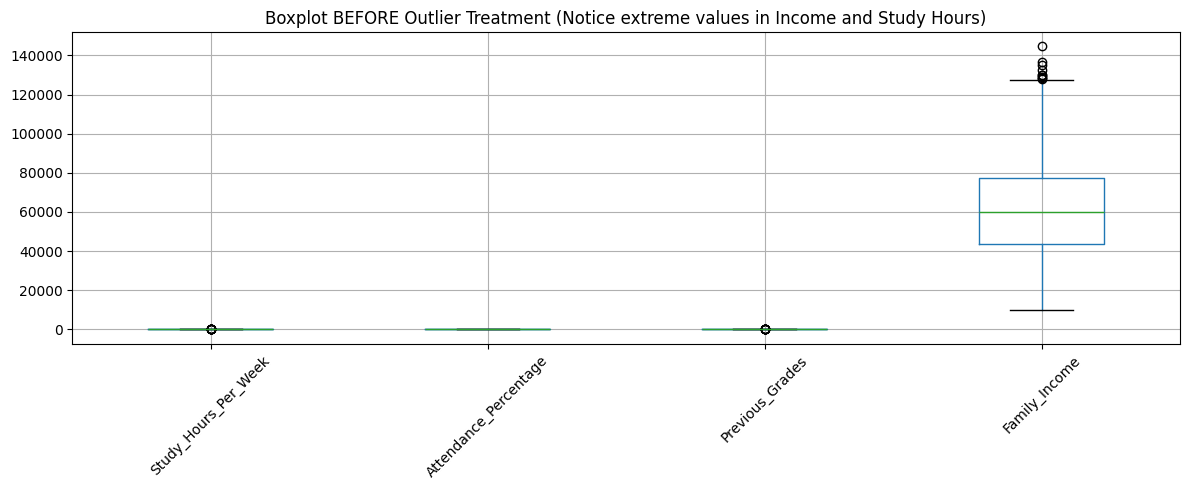

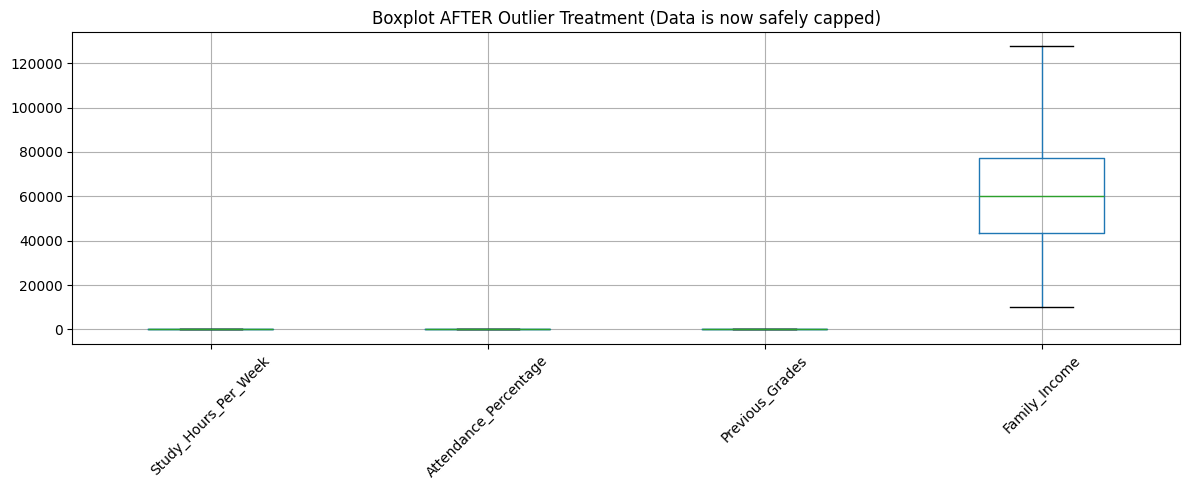

In [8]:
num_cols = ['Study_Hours_Per_Week', 'Attendance_Percentage', 'Previous_Grades', 'Family_Income']

# Plotting BEFORE Outlier Treatment
plt.figure(figsize=(12, 5))
df[num_cols].boxplot(rot=45)
plt.title('Boxplot BEFORE Outlier Treatment (Notice extreme values in Income and Study Hours)')
plt.tight_layout()
plt.show()

# Outlier Treatment using IQR Method
def clip_outliers(dataframe, col):
    Q1 = dataframe[col].quantile(0.25)
    Q3 = dataframe[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    dataframe[col] = np.clip(dataframe[col], lower_bound, upper_bound)
    return dataframe

for col in num_cols:
    df = clip_outliers(df, col)

# Plotting AFTER Outlier Treatment
plt.figure(figsize=(12, 5))
df[num_cols].boxplot(rot=45)
plt.title('Boxplot AFTER Outlier Treatment (Data is now safely capped)')
plt.tight_layout()
plt.show()

## 4. Exploratory Data Analysis & Correlation

/tmp/ipykernel_7048/1122089798.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Dropped_Out', data=df, palette='Set1')


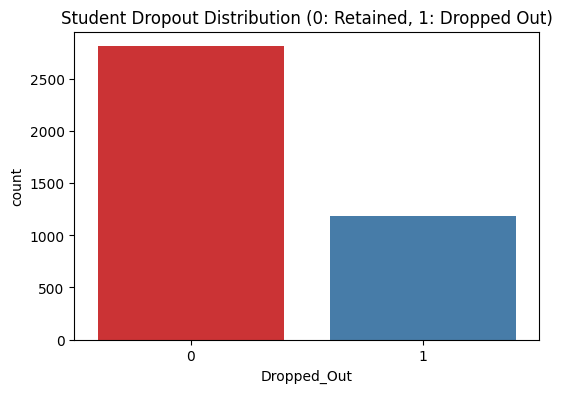

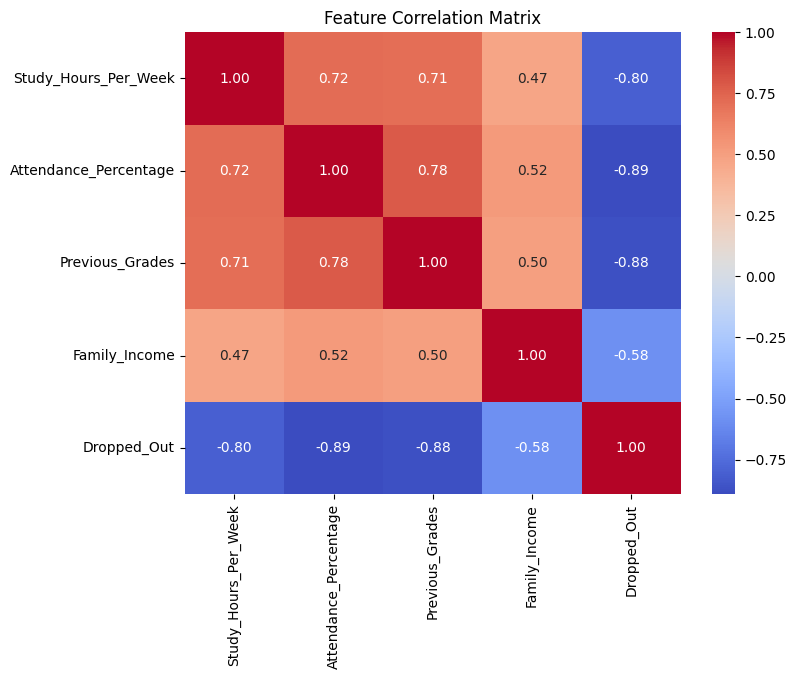

In [9]:
# Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Dropped_Out', data=df, palette='Set1')
plt.title('Student Dropout Distribution (0: Retained, 1: Dropped Out)')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

## 5. Feature Scaling & Data Splitting

In [10]:
X = df.drop(columns=['Dropped_Out'])
y = df['Dropped_Out']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic Regression performs best when features are on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train size: {X_train.shape}')
print(f'Test size : {X_test.shape}')

Train size: (3200, 4)
Test size : (800, 4)


## 6. Model Training (Logistic Regression)

In [11]:
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_scaled, Y_train)

LogisticRegression(class_weight='balanced', random_state=42)

## 7. Model Evaluation

Accuracy Score: 99.88%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       563
           1       1.00      1.00      1.00       237

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



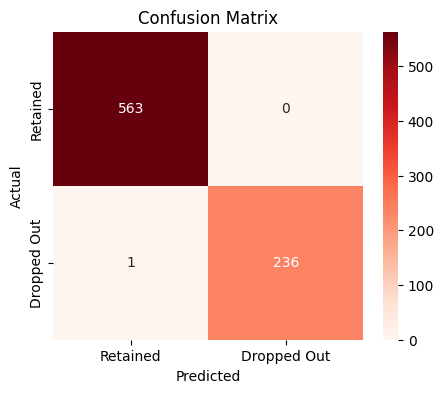

In [12]:
Y_pred = model.predict(X_test_scaled)
acc = accuracy_score(Y_test, Y_pred)

print(f'Accuracy Score: {acc*100:.2f}%\n')
print("Classification Report:")
print(classification_report(Y_test, Y_pred))

# Confusion Matrix
matrix = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Retained', 'Dropped Out'],
            yticklabels=['Retained', 'Dropped Out'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()